In [29]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Problem 1 Setup
# Generate a random positive-definite matrix A and a random vector b
n = 100
np.random.seed(0)
lambda_min = 1.0
lambda_max = 10.0
eigenvalues = np.linspace(lambda_min, lambda_max, n)
Q, _ = np.linalg.qr(np.random.randn(n, n))
A = Q @ np.diag(eigenvalues) @ Q.T
x_true = np.random.randn(n)
b = A @ x_true

In [30]:
# Define the function f(x) = 1/2 x^T A x - b^T x
def f(x):
    return 0.5 * x @ A @ x - b @ x

# Gradient of f(x)
def grad_f(x):
    return A @ x - b

# Compute the exact solution x*
x_star = np.linalg.solve(A, b)  # Since A is likely invertible
f_star = f(x_star)

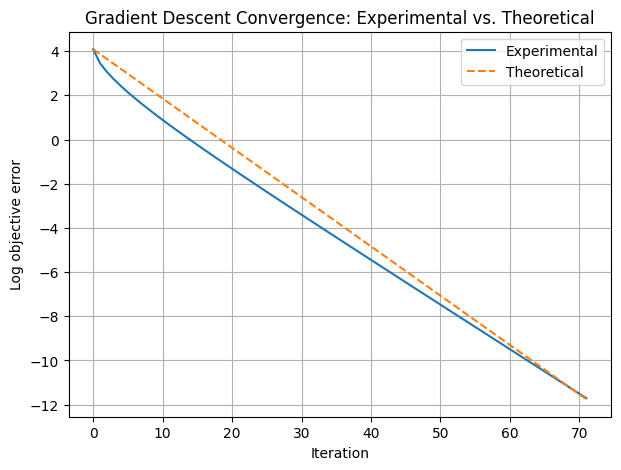

In [31]:
# Task 1: Gradient Descent
# Use a step size alpha = 2/(L+mu), where L is the largest and mu the samllest eigenvalue of A
eigenvals = np.linalg.eigvalsh(A)
L = eigenvals.max()
mu = eigenvals.min()  # smallest eigenvalue
kappa = L / mu
alpha = 2 / (L + mu)

max_iter = 2000
tol = 1e-5
x = np.zeros_like(b)  # Initial guess
f_vals = []           # Will store f(x^t) - f(x_star)

for k in range(max_iter):
    grad = grad_f(x)
    f_val = np.linalg.norm(grad)
    f_vals.append(f_val)
    if f_val < tol:
        break
    x = x - alpha * grad

# Theoretical Convergence Curve
theory_vals = [(1-(2/kappa))**t * f_vals[0] for t in range(len(f_vals))]

# Plot Experimental vs. Theoretical
plt.figure(figsize=(7,5))
plt.plot(np.log(np.abs(f_vals)), label='Experimental')
plt.plot(np.log(np.abs(theory_vals)), '--', label='Theoretical')
plt.xlabel('Iteration')
plt.ylabel('Log objective error')
plt.title('Gradient Descent Convergence: Experimental vs. Theoretical')
plt.legend()
plt.grid(True)
plt.show()

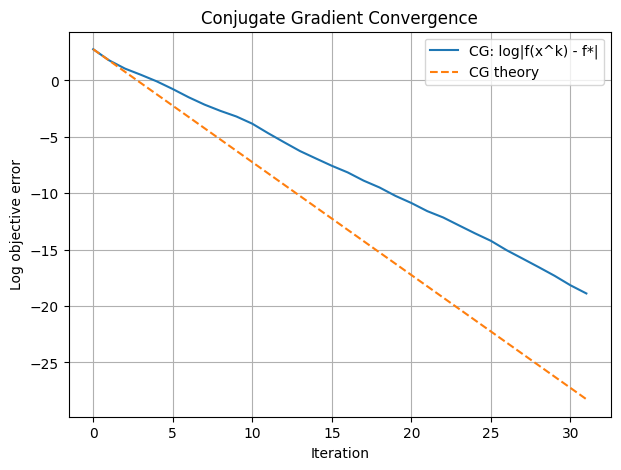

In [ ]:
# Task 2: Conjugate Gradient
max_iter_cg = 2 * n  # typical upper bound for CG
tol_cg = 1e-8

x_cg = np.zeros_like(b)  # initial CG guess
r = b - A @ x_cg         # initial residual
p = r.copy()
f_errors_cg = []

for k in range(max_iter_cg):
    # Check stopping condition
    if np.linalg.norm(r) < tol_cg:
        break

    Ap = A @ p
    alpha_cg = (r.T @ r) / (p.T @ Ap)
    x_cg = x_cg + alpha_cg * p
    r_next = r - alpha_cg * Ap

    beta_cg = (r_next.T @ r_next) / (r.T @ r)
    p = r_next + beta_cg * p
    r = r_next.copy()
    # Record the objective gap for plotting
    f_errors_cg.append(np.linalg.norm(r))

# Theoretical convergence rate:
theory_vals = [((1 - (2 / (np.sqrt(kappa))))**t) * f_errors_cg[0] for t in range(len(f_errors_cg))]

# Plot CG results (Task 2)
plt.figure(figsize=(7,5))
plt.plot(np.log(np.abs(f_errors_cg)), label='CG: log|f(x^k) - f*|')
plt.plot(np.log(np.abs(theory_vals)), '--', label='CG theory')
plt.xlabel('Iteration')
plt.ylabel('Log objective error')
plt.title('Conjugate Gradient Convergence')
plt.legend()
plt.grid(True)
plt.show()

C:\Users\eemel\AppData\Local\Temp\ipykernel_21796\2278714943.py:47: RuntimeWarning: divide by zero encountered in scalar divide
  fista_theory.append(init_gap_fista / (k)**2)


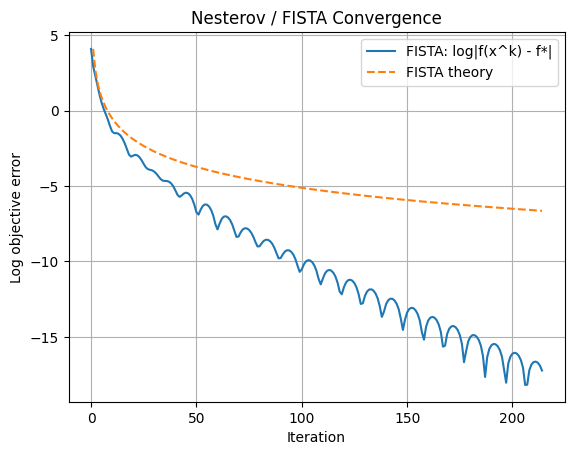

In [ ]:
# Task 3: Nesterov / FISTA
# FISTA steps with step size = 1/L:
#   t_{k+1} = (1/2)(1 + sqrt(1 + 4 t_k^2))
#   x_{k+1} = y_k - (1/L) grad_f(y_k)
#   y_{k+1} = x_{k+1} + ( (t_k -1)/t_{k+1} ) ( x_{k+1} - x_k )


max_iter_fista = 2000
tol_fista = 1e-8

x_fista = np.zeros_like(b)  # x0
y_fista = x_fista.copy()    # y0
t_fista = 1.0

f_errors_fista = []

for k in range(max_iter_fista):

    # Check stopping criterion
    g_y = grad_f(y_fista)
    if np.linalg.norm(g_y) < tol_fista:
        break
    
    f_errors_fista.append(np.linalg.norm(A @ x_fista - b))
    
    # FISTA update
    x_next = y_fista - (1.0/L)*g_y
    t_next = 0.5 * (1 + np.sqrt(1 + 4*(t_fista**2)))

    # Update y
    y_next = x_next + ((t_fista - 1.0)/t_next)*(x_next - x_fista)

    # Shift variables
    x_fista = x_next
    y_fista = y_next
    t_fista = t_next

# Theoretical rate
fista_theory = []
init_gap_fista = f_errors_fista[0]


for k in range(len(f_errors_fista)):
    fista_theory.append(init_gap_fista / (k)**2)

plt.figure()
plt.plot(np.log(np.abs(f_errors_fista)), label='FISTA: log|f(x^k) - f*|')
plt.plot(np.log(np.abs(fista_theory)), '--', label='FISTA theory')
plt.xlabel('Iteration')
plt.ylabel('Log objective error')
plt.title('Nesterov / FISTA Convergence')
plt.grid(True)
plt.legend()
plt.show()

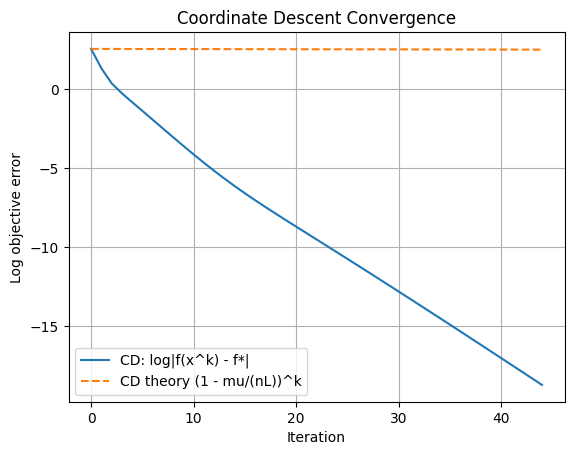

In [ ]:
# Task 4: Coordinate Descent

max_iter_cd = 5000
tol_cd = 1e-8

x_cd = np.zeros(n)
f_errors_cd = []

A_diag = np.diag(A) 

resid = -(b.copy())

for k in range(max_iter_cd):

    for i in range(n):
        x_cd[i] = (b[i] - np.dot(A[i, :], x_cd) + A_diag[i] * x_cd[i]) / A_diag[i]
    
    f_errors_cd.append(np.linalg.norm(A @ x_cd - b))

    # Stopping based on gradient norm or small objective gap
    if np.abs(f_errors_cd[-1]) < tol_cd:
        break
    

# Simple Theoretical Rate
cd_theory = []
if mu > 0:
    init_gap_cd = f_errors_cd[0]
    rate_cd = 1.0 - mu / (n * L)
    for t in range(len(f_errors_cd)):
        cd_theory.append(init_gap_cd * (rate_cd**t))

plt.figure()
plt.plot(np.log(np.abs(f_errors_cd)), label='CD: log|f(x^k) - f*|')
if mu>0:
    plt.plot(np.log(np.abs(cd_theory)), '--', label='CD theory (1 - mu/(nL))^k')
plt.xlabel('Iteration')
plt.ylabel('Log objective error')
plt.title('Coordinate Descent Convergence')
plt.grid(True)
plt.legend()
plt.show()

In [35]:
# Helper functions
def f(A, b, x):
    return 0.5 * x @ A @ x - b @ x

def grad_f(A, b, x):
    return A @ x - b

def run_backslash(A, b):
    """Simulate a MATLAB-style 'backslash' by using np.linalg.solve."""
    t0 = time.time()
    x = np.linalg.solve(A, b)
    elapsed = time.time() - t0
    return x, elapsed

def run_gradient_descent(A, b, x0, max_iter=2000, tol=1e-5):
    """Task 1 method."""
    L = np.linalg.eigvalsh(A).max()
    alpha = 2 / (L + mu)
    x = x0.copy()
    t0 = time.time()
    for it in range(max_iter):
        g = grad_f(A, b, x)
        if np.linalg.norm(g) < tol:
            break
        x -= alpha * g
    elapsed = time.time() - t0
    return x, it+1, elapsed

def run_conjugate_gradient(A, b, x0, max_iter=None, tol=1e-8):
    """Task 2 method."""
    if max_iter is None:
        max_iter = 2 * len(b)
    x = x0.copy()
    r = b - A @ x
    p = r.copy()
    t0 = time.time()
    for it in range(max_iter):
        if np.linalg.norm(r) < tol:
            break
        Ap = A @ p
        alpha_cg = (r.T @ r) / (p.T @ Ap)
        x += alpha_cg * p
        r_next = r - alpha_cg * Ap
        beta = (r_next.T @ r_next)/(r.T @ r)
        p = r_next + beta * p
        r = r_next.copy()
    elapsed = time.time() - t0
    return x, it+1, elapsed

def run_fista(A, b, x0, max_iter=2000, tol=1e-8):
    """Task 3 method (Nesterov / FISTA)."""
    L = np.linalg.eigvalsh(A).max()
    x_k = x0.copy()
    y_k = x_k.copy()
    t_k = 1.0
    t0 = time.time()
    for it in range(max_iter):
        g_y = grad_f(A, b, y_k)
        if np.linalg.norm(grad_f(A, b, x_k)) < tol:
            break
        x_next = y_k - (1.0/L)*g_y
        t_next = 0.5*(1 + np.sqrt(1+4*(t_k**2)))
        y_next = x_next + ((t_k-1)/t_next)*(x_next - x_k)
        x_k = x_next
        y_k = y_next
        t_k = t_next
    elapsed = time.time() - t0
    return x_k, it+1, elapsed

def run_coordinate_descent(A, b, x0, max_iter=20000, tol=1e-8):
    """Task 4 method (cyclic coordinate descent)."""
    n = len(b)
    x = x0.copy()
    t0 = time.time()
    A_diag = np.diag(A) 
    for it in range(max_iter):
        for i in range(n):
            x[i] = (b[i] - np.dot(A[i, :], x) + A_diag[i] * x[i]) / A_diag[i]
    
        # Stopping based on gradient norm or small objective gap
        if np.abs(np.linalg.norm(A @ x - b)) < tol:
            break
    elapsed = time.time() - t0
    return x, it+1, elapsed

# Task 5: Comparisons & Conclusion

dimensions = [100, 500, 1000, 2000, 5000, 10000]
results = []

for n in dimensions:
    eigenvalues = np.linspace(lambda_min, lambda_max, n)
    Q, _ = np.linalg.qr(np.random.randn(n, n))
    A = Q @ np.diag(eigenvalues) @ Q.T
    x_true = np.random.randn(n)
    b = A @ x_true
    
    print(f"\n=== Dimension n = {n} ===")

    # 1) Direct solve
    try:
        x_backslash, time_backslash = run_backslash(A, b)
        err_backslash = abs(f(A, b, x_backslash) - f_star)
        print(f"Backslash: time={time_backslash:.4f}s, final error={err_backslash:.2e}")
    except:
        print("Backslash: failed (likely out of memory or too large)")

    # Prepare initial guess
    x0 = np.zeros_like(b)

    # 2) Gradient Descent
    x_gd, it_gd, time_gd = run_gradient_descent(A, b, x0)
    err_gd = abs(f(A, b, x_gd) - f_star)
    print(f"GD: iters={it_gd}, time={time_gd:.4f}s, final error={err_gd:.2e}")

    # 3) Conjugate Gradient
    x_cg, it_cg, time_cg = run_conjugate_gradient(A, b, x0)
    err_cg = abs(f(A, b, x_cg) - f_star)
    print(f"CG: iters={it_cg}, time={time_cg:.4f}s, final error={err_cg:.2e}")

    # 4) FISTA
    x_fista, it_fista, time_fista = run_fista(A, b, x0)
    err_fista = abs(f(A, b, x_fista) - f_star)
    print(f"FISTA: iters={it_fista}, time={time_fista:.4f}s, final error={err_fista:.2e}")

    # 5) Coordinate Descent
    x_cd, it_cd, time_cd = run_coordinate_descent(A, b, x0)
    err_cd = abs(f(A, b, x_cd) - f_star)
    print(f"CD: iters={it_cd}, time={time_cd:.4f}s, final error={err_cd:.2e}")

    # Store results
    results.append({
        'n': n,
        'backslash_time': time_backslash,
        'gd_iters': it_gd, 'gd_time': time_gd,
        'cg_iters': it_cg, 'cg_time': time_cg,
        'fista_iters': it_fista, 'fista_time': time_fista,
        'cd_iters': it_cd, 'cd_time': time_cd
    })


=== Dimension n = 100 ===
Backslash: time=0.0001s, final error=8.08e-02
GD: iters=72, time=0.0004s, final error=8.08e-02
CG: iters=33, time=0.0004s, final error=8.08e-02
FISTA: iters=198, time=0.0029s, final error=8.08e-02
CD: iters=46, time=0.0059s, final error=8.08e-02

=== Dimension n = 500 ===
Backslash: time=0.0030s, final error=1.02e+03
GD: iters=73, time=0.0028s, final error=1.02e+03
CG: iters=36, time=0.0015s, final error=1.02e+03
FISTA: iters=234, time=0.0168s, final error=1.02e+03
CD: iters=47, time=0.0257s, final error=1.02e+03

=== Dimension n = 1000 ===
Backslash: time=0.0185s, final error=2.50e+03
GD: iters=75, time=0.0091s, final error=2.50e+03
CG: iters=36, time=0.0042s, final error=2.50e+03
FISTA: iters=244, time=0.0574s, final error=2.50e+03
CD: iters=49, time=0.0640s, final error=2.50e+03

=== Dimension n = 2000 ===
Backslash: time=0.1153s, final error=5.21e+03
GD: iters=75, time=0.0503s, final error=5.21e+03
CG: iters=37, time=0.0271s, final error=5.21e+03
FISTA: i